# Survival Analysis: Time-to-Bot-Flag on Spotify

**Bonus research question:** How quickly do accounts transition into bot-like behavior as tenure on Spotify accumulates, and which behavioral predictors accelerate or delay that transition?

**Time-to-event setup**
- **Duration ($T$):** user's reported Spotify tenure in months (bracket midpoint from the `spotify_usage_period` survey item, yielding $T \in \{3, 9, 18, 30\}$).
- **Event ($E$):** the engineered `bot_like` label. Accounts that reach their observed tenure without being flagged are right-censored.

This notebook covers:
1. Survival-data construction
2. Kaplan–Meier estimates overall and by two stratifying variables (skip rate, diversity)
3. Log-rank tests
4. Cox proportional hazards model with 3–6 predictors
5. Proportional-hazards assumption check (scaled Schoenfeld residuals)
6. Integration with the logistic/OLS results

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = ["#1DB954", "#B3B3B3"]

## 2. Construct Survival Data

Load the cleaned dataset and define the duration and event variables.

In [2]:
df = pd.read_csv(os.path.join("..", "data", "cleaned", "spotify_clean_v1.csv"))

df["duration"] = df["usage_months"].astype(float)
df["event"]    = df["bot_like"].astype(int)

print(f"N users: {len(df)}")
print(f"Events (bot-flagged): {df['event'].sum()}  ({df['event'].mean():.1%})")
print(f"Censored:            {(df['event']==0).sum()}\n")
print("Duration distribution (months):")
print(df["duration"].value_counts().sort_index())

N users: 520
Events (bot-flagged): 78  (15.0%)
Censored:            442

Duration distribution (months):
duration
3.0      91
9.0     119
18.0    141
30.0    169
Name: count, dtype: int64


## 3. Kaplan–Meier Survival Estimates

### 3.1 Overall survival

Survival function:
          All users
timeline           
0.0           1.000
3.0           0.990
9.0           0.953
18.0          0.901
30.0          0.688

Median survival: inf months (inf means never reached by end of follow-up)


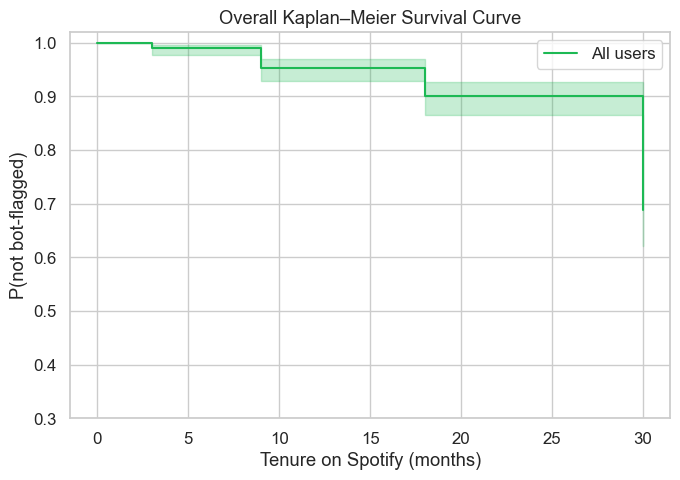

In [3]:
kmf = KaplanMeierFitter()
kmf.fit(df["duration"], df["event"], label="All users")

print("Survival function:")
print(kmf.survival_function_.round(3))
print(f"\nMedian survival: {kmf.median_survival_time_} months (inf means never reached by end of follow-up)")

fig, ax = plt.subplots(figsize=(7, 5))
kmf.plot_survival_function(ax=ax, color=PALETTE[0])
ax.set_xlabel("Tenure on Spotify (months)")
ax.set_ylabel("P(not bot-flagged)")
ax.set_title("Overall Kaplan–Meier Survival Curve")
ax.set_ylim(0.3, 1.02)
plt.tight_layout()
plt.show()

### 3.2 Stratified by skip rate (median split)

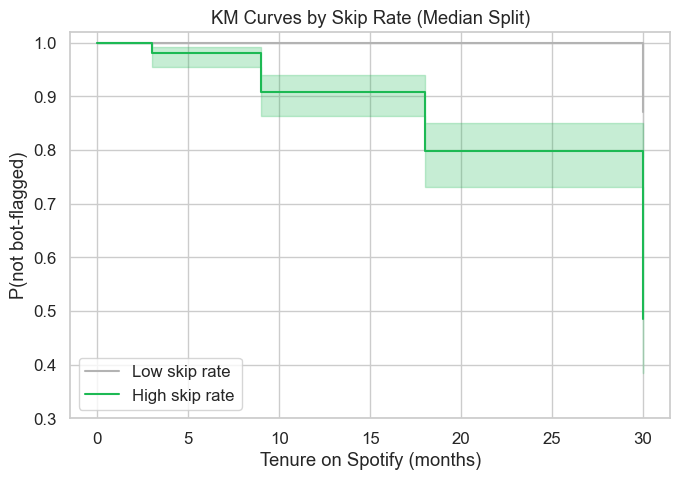

Log-rank (low vs. high skip): chi2 = 56.05, p = 7.082e-14


In [4]:
df["skip_hi"] = (df["skip_rate"] > df["skip_rate"].median()).astype(int)

fig, ax = plt.subplots(figsize=(7, 5))
for val, label, color in [(0, "Low skip rate", PALETTE[1]),
                           (1, "High skip rate", PALETTE[0])]:
    sub = df[df["skip_hi"] == val]
    KaplanMeierFitter().fit(sub["duration"], sub["event"], label=label).plot_survival_function(ax=ax, color=color)

ax.set_xlabel("Tenure on Spotify (months)")
ax.set_ylabel("P(not bot-flagged)")
ax.set_title("KM Curves by Skip Rate (Median Split)")
ax.set_ylim(0.3, 1.02)
plt.tight_layout()
plt.show()

lr = logrank_test(
    df.loc[df.skip_hi == 0, "duration"],
    df.loc[df.skip_hi == 1, "duration"],
    df.loc[df.skip_hi == 0, "event"],
    df.loc[df.skip_hi == 1, "event"],
)
print(f"Log-rank (low vs. high skip): chi2 = {lr.test_statistic:.2f}, p = {lr.p_value:.4g}")

### 3.3 Stratified by listening diversity (median split)

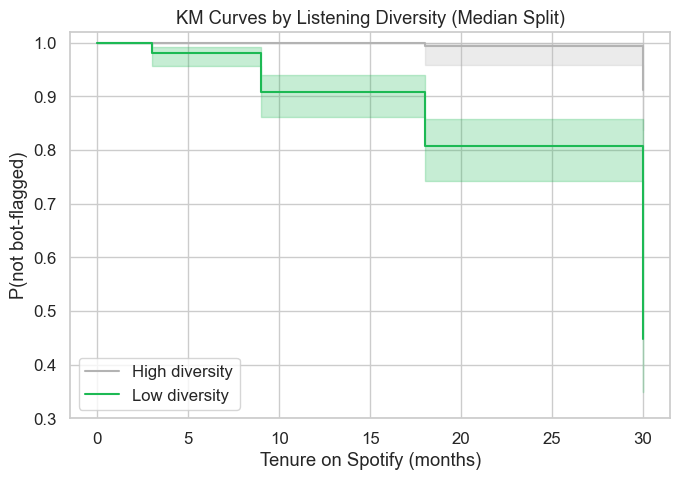

Log-rank (high vs. low diversity): chi2 = 67.46, p = 2.153e-16


In [5]:
df["div_lo"] = (df["diversity_score"] <= df["diversity_score"].median()).astype(int)

fig, ax = plt.subplots(figsize=(7, 5))
for val, label, color in [(0, "High diversity", PALETTE[1]),
                           (1, "Low diversity", PALETTE[0])]:
    sub = df[df["div_lo"] == val]
    KaplanMeierFitter().fit(sub["duration"], sub["event"], label=label).plot_survival_function(ax=ax, color=color)

ax.set_xlabel("Tenure on Spotify (months)")
ax.set_ylabel("P(not bot-flagged)")
ax.set_title("KM Curves by Listening Diversity (Median Split)")
ax.set_ylim(0.3, 1.02)
plt.tight_layout()
plt.show()

lr_div = logrank_test(
    df.loc[df.div_lo == 0, "duration"],
    df.loc[df.div_lo == 1, "duration"],
    df.loc[df.div_lo == 0, "event"],
    df.loc[df.div_lo == 1, "event"],
)
print(f"Log-rank (high vs. low diversity): chi2 = {lr_div.test_statistic:.2f}, p = {lr_div.p_value:.4g}")

## 4. Cox Proportional Hazards Model

Fit a Cox model using four behavioral predictors: skip rate, diversity score, listening time, and age. Report hazard ratios with 95% CIs and the concordance index.

In [6]:
cox_df = df[["duration", "event", "skip_rate", "diversity_score", "listening_time", "age_numeric"]].copy()
cph = CoxPHFitter()
cph.fit(cox_df, duration_col="duration", event_col="event")

print(cph.summary[["coef", "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].round(3))
print(f"\nConcordance index: {cph.concordance_index_:.3f}")
print(f"Log-likelihood:     {cph.log_likelihood_:.2f}")
print(f"AIC (partial):      {cph.AIC_partial_:.2f}")

                  coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%  \
covariate                                                                     
skip_rate        6.521    678.981              209.020             2205.603   
diversity_score -6.586      0.001                0.000                0.025   
listening_time  -0.008      0.992                0.984                1.001   
age_numeric      0.017      1.018                0.981                1.056   

                     p  
covariate               
skip_rate        0.000  
diversity_score  0.000  
listening_time   0.071  
age_numeric      0.354  

Concordance index: 0.935
Log-likelihood:     -332.59
AIC (partial):      673.18


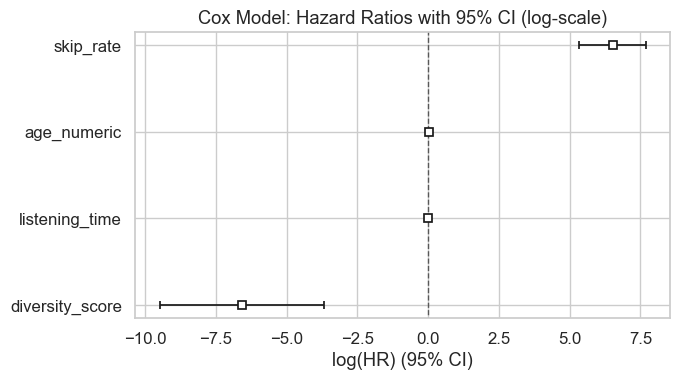

In [7]:
# Forest plot of hazard ratios
fig, ax = plt.subplots(figsize=(7, 4))
cph.plot(ax=ax)
ax.set_title("Cox Model: Hazard Ratios with 95% CI (log-scale)")
plt.tight_layout()
plt.show()

## 5. Proportional-Hazards Assumption Check

Scaled Schoenfeld residual tests: a $p$-value $< .05$ on any covariate suggests the hazard ratio for that variable is not constant over tenure. Visual check via the default `check_assumptions` plots.


   Bootstrapping lowess lines. May take a moment...



The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



C:\Users\ackinet\AppData\Roaming\Python\Python314\site-packages\lifelines\utils\lowess.py:54: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.6137999346762875e-18.
  beta = linalg.solve(A, b, assume_a="pos", check_finite=False)
C:\Users\ackinet\AppData\Roaming\Python\Python314\site-packages\lifelines\utils\lowess.py:54: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1997125462901172e-17.
  beta = linalg.solve(A, b, assume_a="pos", check_finite=False)
C:\Users\ackinet\AppData\Roaming\Python\Python314\site-packages\lifelines\utils\lowess.py:54: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.275925271638604e-17.
  beta = linalg.solve(A, b, assume_a="pos", check_finite=False)




1. Variable 'skip_rate' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 5), you can include `strata=['skip_rate', ...]` in the
call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...



C:\Users\ackinet\AppData\Roaming\Python\Python314\site-packages\lifelines\utils\lowess.py:54: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1997125462901172e-17.
  beta = linalg.solve(A, b, assume_a="pos", check_finite=False)
C:\Users\ackinet\AppData\Roaming\Python\Python314\site-packages\lifelines\utils\lowess.py:54: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.228277130725596e-17.
  beta = linalg.solve(A, b, assume_a="pos", check_finite=False)



   Bootstrapping lowess lines. May take a moment...



C:\Users\ackinet\AppData\Roaming\Python\Python314\site-packages\lifelines\utils\lowess.py:54: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1997125462901172e-17.
  beta = linalg.solve(A, b, assume_a="pos", check_finite=False)
C:\Users\ackinet\AppData\Roaming\Python\Python314\site-packages\lifelines\utils\lowess.py:54: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.369662784353578e-18.
  beta = linalg.solve(A, b, assume_a="pos", check_finite=False)
C:\Users\ackinet\AppData\Roaming\Python\Python314\site-packages\lifelines\utils\lowess.py:54: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.6137999346762875e-18.
  beta = linalg.solve(A, b, assume_a="pos", check_finite=False)



2. Variable 'listening_time' failed the non-proportional test: p-value is 0.0285.

   Advice 1: the functional form of the variable 'listening_time' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'listening_time' using pd.cut, and then specify it in
`strata=['listening_time', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...



C:\Users\ackinet\AppData\Roaming\Python\Python314\site-packages\lifelines\utils\lowess.py:54: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1997125462901172e-17.
  beta = linalg.solve(A, b, assume_a="pos", check_finite=False)
C:\Users\ackinet\AppData\Roaming\Python\Python314\site-packages\lifelines\utils\lowess.py:54: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.228277130725596e-17.
  beta = linalg.solve(A, b, assume_a="pos", check_finite=False)
C:\Users\ackinet\AppData\Roaming\Python\Python314\site-packages\lifelines\utils\lowess.py:54: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.6137999346762875e-18.
  beta = linalg.solve(A, b, assume_a="pos", check_finite=False)



---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



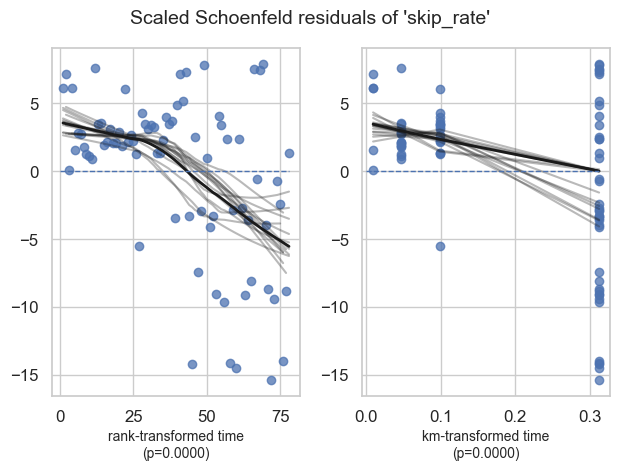

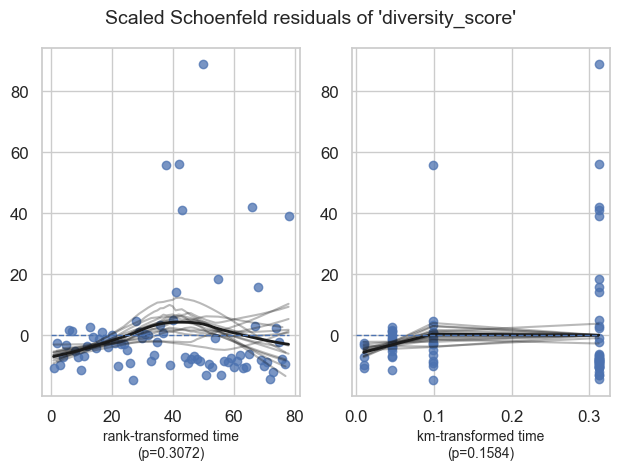

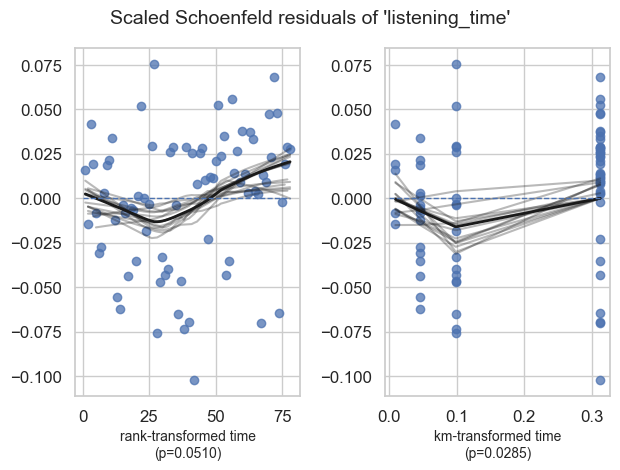

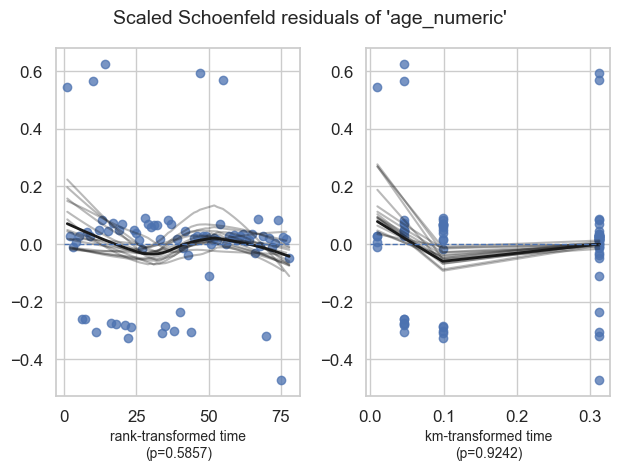

In [8]:
_ = cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=True)

## 6. Integration with Logistic and OLS Results

Compare the Cox hazard ratios with the logistic odds ratios from `02_logistic_regression.ipynb` and the OLS coefficients from `03_multiple_regression.ipynb`:

- Skip rate and diversity should be the dominant predictors in both frames (same directional story).
- Listening time may flip sign between the logistic and Cox frames because Cox conditions on tenure explicitly.
- Age should remain non-significant across models.

Written interpretation of these comparisons lives in the Discussion section of the paper (§Integration with the logistic model).